In [1]:
import json
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.patches as mpatches
from pathlib import Path
from collections import defaultdict

# Regular graphs

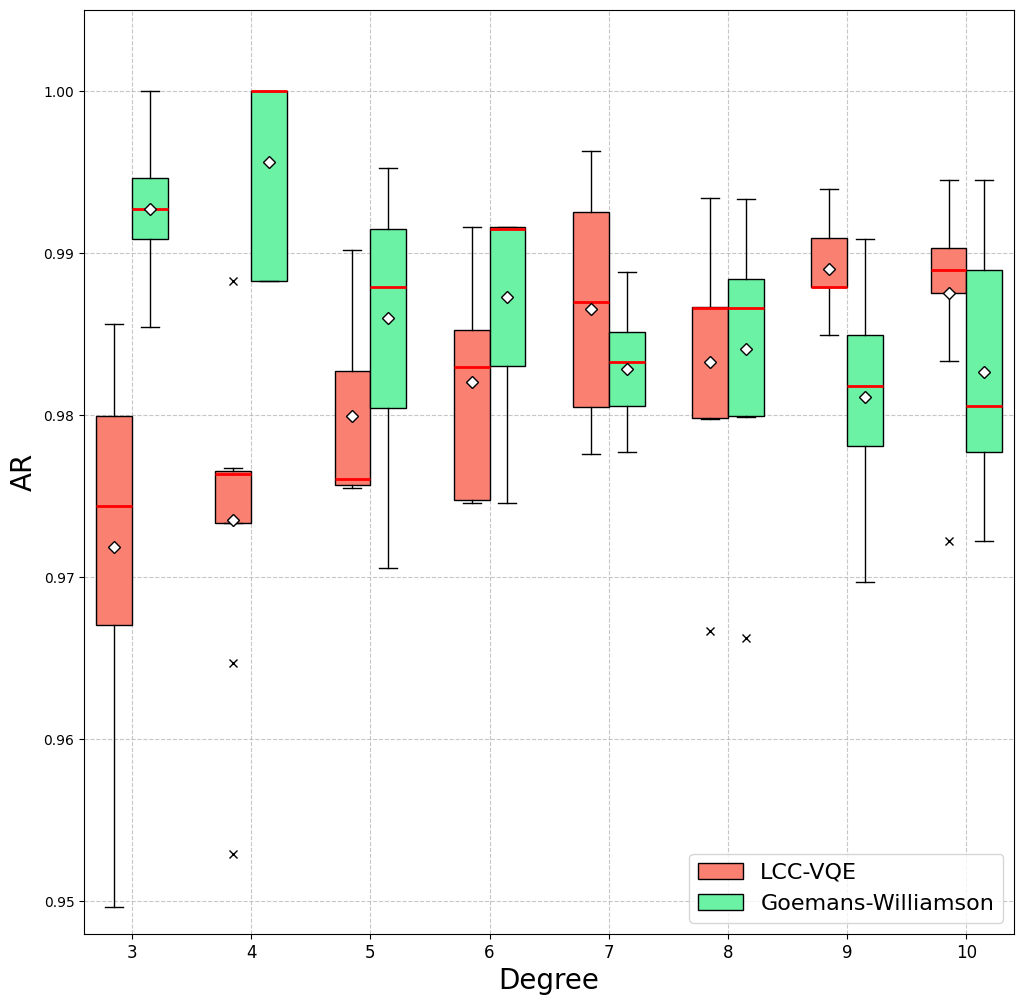

In [2]:
TARGET_DIR = Path('LccData')
pattern = re.compile(r"n100_reg(\d+)_seed(\d+)\.json") 

data_dict = defaultdict(lambda: {"gw": [], "lcc": []})

for file in TARGET_DIR.glob("n100_reg*_seed*.json"):
    match = pattern.match(file.name)
    if not match:
        continue
    
    try:
        reg_value = int(match.group(1))   
        seed_value = int(match.group(2))   
        
        with open(file, "r") as f:
            content = json.load(f)
            
            expectations = content.get("expectations", [])
            gw_max = content.get("gw_max", 0)
            true_obj = content.get("true_obj", 1)   
            normalized_gw_max = gw_max / true_obj
            
            if expectations:
                max_expectation = max(expectations) / true_obj
            else:
                max_expectation = 0.0
            
            data_dict[reg_value]["gw"].append(normalized_gw_max)
            data_dict[reg_value]["lcc"].append(max_expectation)
            
    except json.JSONDecodeError:
        print(f"Error decoding {file.name}")

unique_reg_values = sorted(data_dict.keys())

gw_data = []
lcc_data = []

for rv in unique_reg_values:
    gw_data.append(data_dict[rv]["gw"])
    lcc_data.append(data_dict[rv]["lcc"])

# plot box
plt.figure(figsize=(12, 12))  
box_width = 0.6

group_spacing = 2  
group_indices = np.arange(len(unique_reg_values))
x_positions_lcc = group_spacing * group_indices - box_width/2
x_positions_gw  = group_spacing * group_indices + box_width/2

# LCC-VQE boxplot
bp_lcc = plt.boxplot(
    lcc_data,
    positions=x_positions_lcc,
    widths=box_width,
    patch_artist=True,    
    showfliers=True,     
    flierprops={"marker": "x", "markersize": 6},
)

# GW boxplot
bp_gw = plt.boxplot(
    gw_data,
    positions=x_positions_gw,
    widths=box_width,
    patch_artist=True,
    showfliers=True,
    flierprops={"marker": "x", "markersize": 6},
)

for patch in bp_lcc['boxes']:
    patch.set_facecolor("salmon")
for patch in bp_gw['boxes']:
    patch.set_facecolor("#6BF2A5")

for median in bp_lcc['medians']:
    median.set(color='red', linewidth=2)
for median in bp_gw['medians']:
    median.set(color='red', linewidth=2)

plt.xticks(group_spacing * group_indices, unique_reg_values, fontsize=12)
plt.xlabel("Degree", fontsize=20)
plt.ylim(0.948, 1.005)
plt.ylabel("AR", fontsize=20)
plt.grid(True, linestyle="--", alpha=0.7)

for i, data in enumerate(lcc_data):
    avg_val = np.mean(data)
    plt.plot(group_spacing * i - box_width/2, avg_val, 
             marker='D', markersize=6, markeredgecolor='black', markerfacecolor='white', zorder=3)
for i, data in enumerate(gw_data):
    avg_val = np.mean(data)
    plt.plot(group_spacing * i + box_width/2, avg_val, 
             marker='D', markersize=6, markeredgecolor='black', markerfacecolor='white', zorder=3)

red_patch = mpatches.Patch(facecolor="salmon", edgecolor='black', label='LCC-VQE')
green_patch = mpatches.Patch(facecolor="#6BF2A5", edgecolor='black', label='Goemans-Williamson')

plt.legend(handles=[red_patch, green_patch],
           loc='lower right',
           fancybox=True,
           frameon=True,
           prop={'size': 16})

# plt.savefig("GW_LCC100.pdf", format="pdf", bbox_inches='tight')
plt.show()

# $G(n,p)$ graphs

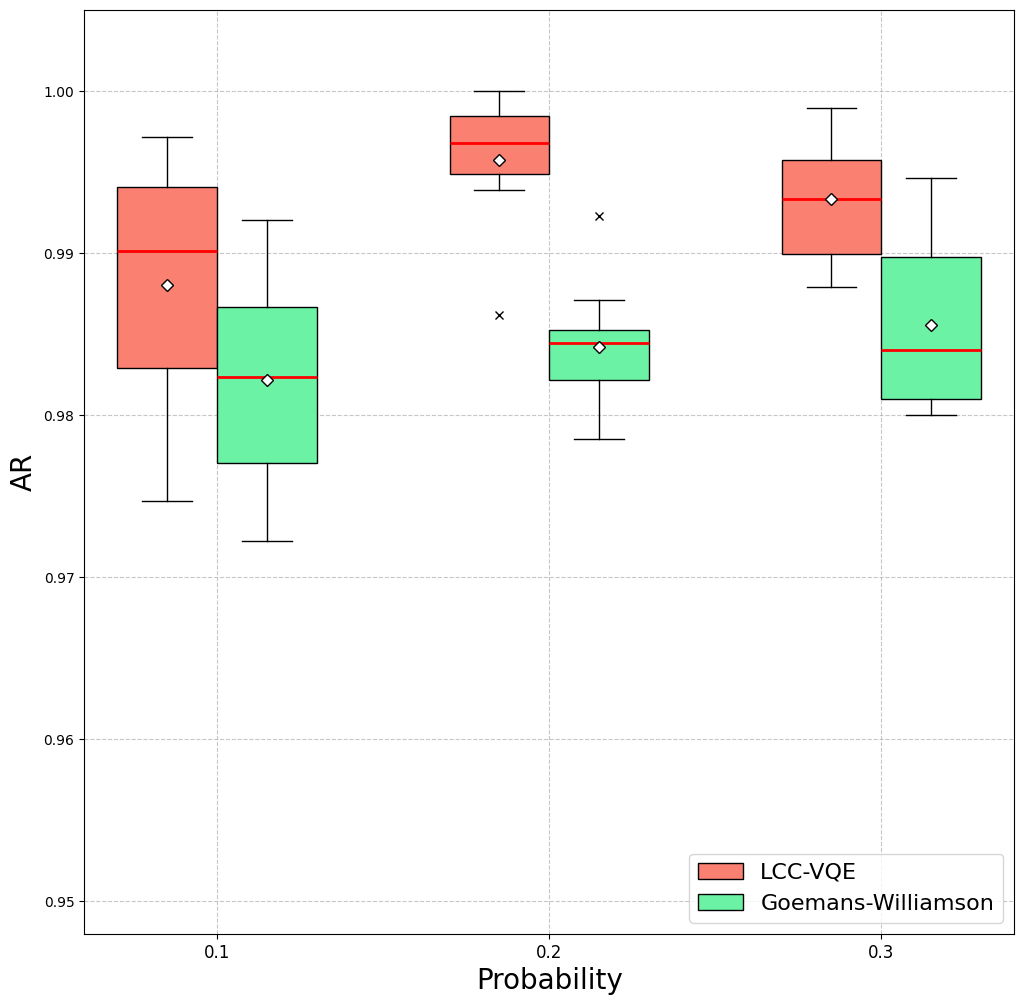

In [3]:
TARGET_DIR = Path('LccData/cobyla/n100_gnp') 
pattern = re.compile(r"n100_gnp(\d+)_seed(\d+)\.json")

data_dict = defaultdict(lambda: {"gw": [], "lcc": []})

for file in TARGET_DIR.glob("n100_gnp*_seed*.json"):
    match = pattern.match(file.name)
    if not match:
        continue
    
    try:
        reg_value = int(match.group(1)) * 0.1  
        seed_value = int(match.group(2))    
        
        with open(file, "r") as f:
            content = json.load(f)
            
            expectations = content.get("expectations", [])
            gw_max = content.get("gw_max", 0)
            true_obj = content.get("true_obj", 1)
            
            normalized_gw_max = gw_max / true_obj
            
            if expectations:
                max_expectation = max(expectations) / true_obj
            else:
                max_expectation = 0.0
            
            data_dict[reg_value]["gw"].append(normalized_gw_max)
            data_dict[reg_value]["lcc"].append(max_expectation)
            
    except json.JSONDecodeError:
        print(f"Error decoding {file.name}")

unique_reg_values = sorted(data_dict.keys())

gw_data = []
lcc_data = []

for rv in unique_reg_values:
    gw_data.append(data_dict[rv]["gw"])
    lcc_data.append(data_dict[rv]["lcc"])

plt.figure(figsize=(12, 12)) 
box_width = 0.6

group_spacing = 2 
group_indices = np.arange(len(unique_reg_values))
x_positions_lcc = group_spacing * group_indices - box_width/2
x_positions_gw  = group_spacing * group_indices + box_width/2

bp_lcc = plt.boxplot(
    lcc_data,
    positions=x_positions_lcc,
    widths=box_width,
    patch_artist=True,   
    showfliers=True,      
    flierprops={"marker": "x", "markersize": 6},
)

bp_gw = plt.boxplot(
    gw_data,
    positions=x_positions_gw,
    widths=box_width,
    patch_artist=True,
    showfliers=True,
    flierprops={"marker": "x", "markersize": 6},
)

for patch in bp_lcc['boxes']:
    patch.set_facecolor("salmon")
for patch in bp_gw['boxes']:
    patch.set_facecolor("#6BF2A5")

for median in bp_lcc['medians']:
    median.set(color='red', linewidth=2)
for median in bp_gw['medians']:
    median.set(color='red', linewidth=2)

tick_positions = group_spacing * group_indices
tick_labels    = [f"{rv:.1f}" for rv in unique_reg_values]
plt.xticks(tick_positions, tick_labels, fontsize=12)
plt.xlabel("Probability", fontsize=20)
plt.ylim(0.948, 1.005)
plt.ylabel("AR", fontsize=20)
plt.grid(True, linestyle="--", alpha=0.7)

for i, data in enumerate(lcc_data):
    avg_val = np.mean(data)
    plt.plot(group_spacing * i - box_width/2, avg_val, 
             marker='D', markersize=6, markeredgecolor='black', markerfacecolor='white', zorder=3)
for i, data in enumerate(gw_data):
    avg_val = np.mean(data)
    plt.plot(group_spacing * i + box_width/2, avg_val, 
             marker='D', markersize=6, markeredgecolor='black', markerfacecolor='white', zorder=3)

red_patch = mpatches.Patch(facecolor="salmon", edgecolor='black', label='LCC-VQE')
green_patch = mpatches.Patch(facecolor="#6BF2A5", edgecolor='black', label='Goemans-Williamson')

plt.legend(handles=[red_patch, green_patch],
           loc='lower right',
           fancybox=True,
           frameon=True,
           prop={'size': 16})

# plt.savefig("GW_LCC100gnp.pdf", format="pdf", bbox_inches='tight')
plt.show()